<a href="https://colab.research.google.com/github/FernandoBarc/EarthObsAdv2026/blob/main/EarthObsAdv_Flood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import ee
import geemap.core as geemap
# Authenticate and initialize the Earth Engine API
ee.Authenticate()
ee.Initialize(project='aqueous-vial-492012-a4') #GeoInfFJBF`

In [ ]:
import pandas as pd
import numpy as np
import math
import geemap
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.plot import show
import joblib
import folium
import geopandas as gpd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
# from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (roc_curve, auc, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score,classification_report )
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.feature_selection import SequentialFeatureSelector




# **Data loading**
Load Sentinel 1-SAR and Sentinel 2-TOA Reflectance data
Filters by date, and boundaries of the AOI **Alamo Region of the north of Veracruz, Mexico**


# Sentinel-1 SAR
VV_pre, VV_post, VH_pre, VH_post
ΔVV, ΔVH

**Índices RADAR del mismo catálogo**
VVVHR (VV/VH), VHVVD (VH−VV), DPDD ((VV+VH)/√2)

**Coherencia InSAR**
coh_pre, coh_co

# Sentinel-2 Multispectral Top of Atmosphere Reflectance

**Reflectancias base**: B, G, R, NIR, SWIR1, SWIR2

**Optical Indexes**:
MNDWI -
NDWI -  
AWEIsh -
NDVI -
NDBI -
NDTI -

**Auxiliary data**: DEM, slope, HAND, dist_river, building_mask

In [ ]:
# Functions to calculate different indexes for the optical bands

def maskCloudsv2(image):
  cloudProb = image.select('MSK_CLDPRB')
  darkObjProb = image.select('MSK_CLASSI_OPAQUE')
  cirrusProb = image.select('MSK_CLASSI_CIRRUS')
  cloudMask = cloudProb.lt(5)
  darkObjMask = darkObjProb.lt(80)
  cirrusMask = cirrusProb.lt(15)
  return image.updateMask(cloudMask).divide(10000)  #.updateMask(darkObjMask).updateMask(cirrusMask).divide(10000) # Includes scaling factor

def addMNDWI(input):
  # Modified Normalized Difference Water Index (G−S1)/(G+S1)
  mndwi = input.normalizedDifference(['B3', 'B11']).rename("MNDWI")
  return input.addBands(mndwi)

def addNDWI(input):
  # Normalized Difference Water Index (G−N)/(G+N)
  ndwi = input.normalizedDifference(['B3', 'B8']).rename("NDWI")
  return input.addBands(ndwi)

def addNDVI(input):
  ndvi = input.normalizedDifference(['B5', 'B4']).rename("NDVI")
  return input.addBands(ndvi)

def addNDBI(input):
  # Normalized Difference Built-Up Index (S1−N)/(S1+N)
  ndbi = input.normalizedDifference(['B5', 'B4']).rename("NDBI")
  return input.addBands(ndbi)

def addNDTI(input):
  # Normalized Difference Turbidity Index (R−G)/(R+G)
  ndti = input.normalizedDifference(['B5', 'B4']).rename("NDTI")
  return input.addBands(ndti)

def addAWEIsh(image):
    # Automated Water Extraction Index with Shadows Elimination
    # Formula: B + 2.5 * G - 1.5 * (N + S1) - 0.25 * S2
    aweish = image.expression(
        'B + 2.5 * G - 1.5 * (N + S1) - 0.25 * S2', {
            'B': image.select('B2'),
            'G': image.select('B3'),
            'N': image.select('B8'),
            'S1': image.select('B11'),
            'S2': image.select('B12')
        }
    ).toFloat().rename('AWEIsh') # Rename the resulting band to 'AWEIsh'
    # Add the new band back to the original input image
    return image.addBands(aweish)


bandsOfInterest = [
  'B1_diff',
  'B2_diff',
  'B3_diff',
  'B4_diff',
  'B5_diff',
  'B6_diff',
  'B7_diff',
  'B8_diff',
  'B8A_diff',
  'B9_diff',
  'B11_diff',
  'B12_diff',
  'MNDWI_diff',
  'NDWI_diff',
  'NDVI_diff',
  'NDBI_diff',
  'NDTI_diff',
  'AWEIsh_diff',
  #'VH_diff'
  ]

OpticalBands = [
  'B1_diff',
  'B2_diff',
  'B3_diff',
  'B4_diff',
  'B5_diff',
  'B6_diff',
  'B7_diff',
  'B8_diff',
  'B8A_diff',
  'B9_diff',
  'B11_diff',
  'B12_diff',
]

SpectralIndexes = [
  'MNDWI_diff',
  'NDWI_diff',
  'NDVI_diff',
  'NDBI_diff',
  'NDTI_diff',
  'AWEIsh_diff',
]

# Definition of the Area of Interest around Álamo town.
aoi = ee.FeatureCollection('projects/aqueous-vial-492012-a4/assets/geometry_AlamoTight')

# Timeframes for before and after
before_start= '2025-09-01'
before_end='2025-10-05'

after_start='2025-10-10'
after_end='2025-10-15'


In [ ]:
# Set SAR Parameters
polarization = "VH"       # 'VH' is preferred for flood mapping; can also use 'VV' but not much difference tbh
pass_direction = "DESCENDING"  # 'DESCENDING' or 'ASCENDING'
difference_threshold = 1.2    # Custom threshold for (after_flood / before_flood)
smoothing_radius = 50
relative_orbit = 143

# Load and filter Sentinel-1 GRD data
s1before = (ee.ImageCollection('COPERNICUS/S1_GRD')
              .filterDate(before_start, before_end) # Filter by date ranges
              .filter(ee.Filter.eq('instrumentMode', 'IW'))
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', polarization))
              .filter(ee.Filter.eq('orbitProperties_pass', pass_direction))
              .filter(ee.Filter.eq('resolution_meters', 10))
              .filter(ee.Filter.eq('relativeOrbitNumber_start',relative_orbit ))
              .filterBounds(aoi)
              .select(polarization)
              .mosaic() # Create mosaics and clip to the AOI
              .clip(aoi)
              .focal_mean(smoothing_radius, 'circle', 'meters')).toFloat() # Apply speckle reduction filter (Smoothing) and converting to float to


s1after = (ee.ImageCollection('COPERNICUS/S1_GRD')
              .filterDate(after_start, after_end) # Filter by date ranges
              .filter(ee.Filter.eq('instrumentMode', 'IW'))
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', polarization))
              .filter(ee.Filter.eq('orbitProperties_pass', pass_direction))
              .filter(ee.Filter.eq('resolution_meters', 10))
              .filter(ee.Filter.eq('relativeOrbitNumber_start',relative_orbit ))
              # .map(mask_edge)
              .filterBounds(aoi)
              .select(polarization)
              .mosaic() # Create mosaics and clip to the AOI
              .clip(aoi)
              .focal_mean(smoothing_radius, 'circle', 'meters')).toFloat() # Apply speckle reduction filter (Smoothing)

s1ratio = s1after.divide(s1before)
s1ratio_binary = s1ratio.focal_mean(smoothing_radius, 'circle', 'meters').gt(difference_threshold)

In [ ]:
s2before = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate(before_start, before_end)
    .filterBounds(aoi)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(maskCloudsv2)
    .map(addMNDWI)
    .map(addNDWI)
    .map(addNDVI)
    .map(addNDBI)
    .map(addNDTI)
    .map(addAWEIsh)
    .mosaic()
    .clip(aoi)
)

s2after = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate(after_start, after_end)
    .filterBounds(aoi)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(maskCloudsv2) #mask_s2_clouds maskCloudsv2
    .map(addMNDWI)
    .map(addNDWI)
    .map(addNDVI)
    .map(addNDBI)
    .map(addNDTI)
    .map(addAWEIsh)
    .mosaic()
    .clip(aoi)
)

# Adding the Sentinel 2 SAR data to the classification dataset
# This was later undone to avoid overfitting the data to a single variable,
# the goal of the experiment is not to improve the classification using SAR and Optical
# instead is to provide a tool when SAR is not available. Also could be seen as double
# checking if the algorithm is reliable.
# s2before = s2before.addBands(s1before.select("VH"))
# s2after = s2after.addBands(s1after.select("VH"))

In [ ]:
# Just to make sure both files share the exact same band names
commonBands = s2before.bandNames().filter(
    ee.Filter.inList('item', s2after.bandNames())
)
s2before_aligned = s2before.select(commonBands)
s2after_aligned  = s2after.select(commonBands)

# Instead of passing both bands to the Classification algorithm, pass only the
# difference between before and after to reduce dimensionality of the dataset
diff_bands = commonBands.map(lambda b: ee.String(b).cat('_diff'))
s2_diff = s2before_aligned.subtract(s2after_aligned).rename(diff_bands)

# Rename originals with _pre / _post suffixes to avoid collisions
pre_names  = s2before.bandNames().map(lambda b: ee.String(b).cat('_pre'))
post_names = s2after.bandNames().map(lambda b: ee.String(b).cat('_post'))

s2before_r = s2before.rename(pre_names)
s2after_r  = s2after.rename(post_names)

# All bands before, after and diff now are stored in the same Collection, to simply data management
ds2 = s2before_r.addBands(s2after_r).addBands(s2_diff)

# Sanity check of previous process
# print('Total bands:', ds2.bandNames().size().getInfo())
# print(ds2.select(bandsOfInterest).bandNames().getInfo()) #.select(bandsOfInterest)

# Export to drive

The actual classification of the data will be done using Python tools instead of the GEE classification algorithms. Since python provides better control over hyperparameters.

In [ ]:
# Image containing SAR binary mask
task_img_s1_diff_bin = ee.batch.Export.image.toDrive(
    image=s1ratio_binary.clip(aoi.geometry()),
    description='AlamoFlood_SAR_Mask',
    folder='GEE_exports',
    fileNamePrefix='AlamoFlood_SAR_Mask',
    region=aoi.geometry(),
    scale=10,
    maxPixels=1e13,
    fileFormat='GeoTIFF',
)
# task_img_s1_diff_bin.start()


# # Image containing optical bands
task_img = ee.batch.Export.image.toDrive(
    image=ds2.select(bandsOfInterest).clip(aoi.geometry()),
    description='features_alamo',
    folder='GEE_exports',
    fileNamePrefix='features_alamo',
    region=aoi.geometry(),
    scale=10,
    maxPixels=1e13,
    fileFormat='GeoTIFF',
)
# task_img.start()



# # Image containing optical bands
task_img_after = ee.batch.Export.image.toDrive(
    image=s2after.clip(aoi.geometry()),
    description='alamo_after',
    folder='GEE_exports',
    fileNamePrefix='alamo_after',
    region=aoi.geometry(),
    scale=10,
    maxPixels=1e13,
    fileFormat='GeoTIFF',
)
# task_img_after.start()

# # In GEE
# task_img = ee.batch.Export.image.toDrive(
#     image=SVMClassified.clip(aoi.geometry()),
#     description='AlamoSVMClassified',
#     folder='GEE_exports',
#     fileNamePrefix='AlamoSVMClassified',
#     region=aoi.geometry(),
#     scale=10,
#     maxPixels=1e13,
#     fileFormat='GeoTIFF',
# )
# # task_img.start()

# Data sampling
For the first classification algorithm the GEE classification toolbox is used.

Samples are stratified to ensure unbiased estimations, since the dataset is not balances across the classes.

A set of 1000 points were selected since there is only two classes and the size of the dataset is not that big: N pixels in total.

geometries were removed to improve overfitting to a specific regions of the image and make it a more generalist classification model.

The traning and validation split was selected according to existing literature recommendations.

Finally both sample bins are exported as a data frame back to python to perform model training.

In [ ]:
training = ds2.select(bandsOfInterest).addBands(s1ratio_binary.rename('class')).stratifiedSample(
  region = aoi,
  scale = 10,
  numPoints = 2000,  # Number of Samples
  classBand = "class",
  seed = 25, # Ensures repeatability of the sampling
  geometries = False # We don't need to save sample points as geometries
)

# Randomly split the data into a training set (80%) and a validation set (20%)
training = training.randomColumn();
trainset = training.filter(ee.Filter.lt('random', 0.80))
valset = training.filter(ee.Filter.gte('random', 0.80))

# Export the samples to a pandas Dataframe to perform the evaluations
df_train = geemap.ee_to_df(trainset) # training
df_val   = geemap.ee_to_df(valset)

# corr_matrix = df_train.drop(columns=["class","random"]).corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', cbar=True)
# plt.title('Correlation Matrix Heatmap')
# plt.show()




# SVM Classification Model

First

In [ ]:


# --- Split features and label ---
X_train = df_train[bandsOfInterest].values
y_train = df_train['class'].astype(int).values
X_val   = df_val[bandsOfInterest].values
y_val   = df_val['class'].astype(int).values


crossvalidation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Pipeline: scaler + SVM with class weighting ---
clf_svm = Pipeline([
    ('scaler', StandardScaler()),                    # critical for SVM
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',                     # handles imbalance
        probability=True,                            # enables predict_proba
        random_state=42,
    )),
])

sfs_svm = SequentialFeatureSelector(
    clf_svm,
    n_features_to_select='auto',
    tol=0.001,                       # stop when CV score improves by < 0.1%
    direction='forward',
    scoring='accuracy',                    # or 'roc_auc' if you care about ranking
    cv=crossvalidation,
    n_jobs=-1,
)
sfs_svm.fit(X_train, y_train)

selected_features_svm = sfs_svm.get_feature_names_out(input_features = bandsOfInterest)
print('Selected:', list(selected_features_svm))

# clf.fit(X_train, y_train)

# # --- Evaluate ---
# y_pred = clf.predict(X_val)
# y_prob = clf.predict_proba(X_val)[:, 1]

# print(confusion_matrix(y_val, y_pred))
# print(classification_report(y_val, y_pred, digits=4, target_names=['no_flood', 'flood']))
# print(f"ROC-AUC: {roc_auc_score(y_val, y_prob):.4f}")

Selected: ['B1_diff', 'B9_diff', 'B11_diff', 'B12_diff', 'MNDWI_diff', 'NDWI_diff', 'NDVI_diff', 'AWEIsh_diff']


In [ ]:
# --- Split features and label ---
X_train = df_train[selected_features_svm].values
y_train = df_train['class'].astype(int).values
X_test   = df_val[selected_features_svm].values
y_test   = df_val['class'].astype(int).values

param_grid = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.0001, 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    clf_svm,
    param_grid,
    cv=crossvalidation,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV accuracy:', grid.best_score_)

clf_svm = grid.best_estimator_




Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}
Best CV accuracy: 0.8686837870126279


Classification Report for Support Vector Machine:
              precision    recall  f1-score   support

    No Flood     0.9348    0.8171    0.8720       421
       Flood     0.8285    0.9394    0.8805       396

    accuracy                         0.8764       817
   macro avg     0.8816    0.8782    0.8762       817
weighted avg     0.8833    0.8764    0.8761       817


Confusion Matrix SVM:
                 Predicted No Flood  Predicted Flood
Actual No Flood                 344               77
Actual Flood                     24              372


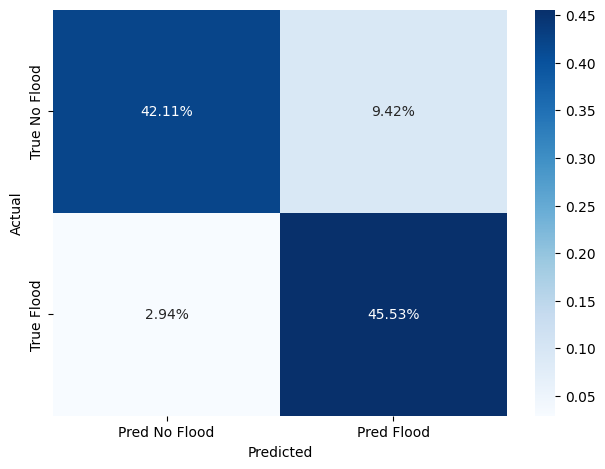

In [ ]:
# # Evaluate the model using cross-validation
xval_score = cross_val_score(clf_svm, X_train, y_train, cv=crossvalidation)

# Compute the basic statistics
accuracy_mean = np.average(xval_score)
accuracy_std = np.std(xval_score)

# Fit the classifier to the training data
clf_svm.fit(X_train, y_train)

# Make predictions on the test data
yp = clf_svm.predict(X_test)

# Get probability values
yprob = clf_svm.predict_proba(X_test)


# Define ONCE, in encoding order (index = class integer)
class_labels = [0, 1]
class_names  = ['No Flood', 'Flood']   # 0 = No Flood, 1 = Flood

# --- Classification report (labels + target_names kept in lockstep) ---
class_report = classification_report(
    y_test, yp,
    labels=class_labels,
    target_names=class_names,
    digits=4,
)
print('Classification Report for Support Vector Machine:')
print(class_report)

# --- Confusion matrix with explicit label order ---
conf_matrix = confusion_matrix(y_test, yp, labels=class_labels)

# Rows = actual, Cols = predicted; both follow class_names order
cm_df = pd.DataFrame(
    conf_matrix,
    index=[f'Actual {n}' for n in class_names],
    columns=[f'Predicted {n}' for n in class_names],
)
print('\nConfusion Matrix SVM:')
print(cm_df)

# --- Heatmap (normalized), correctly labeled ---
sns.heatmap(
    conf_matrix / conf_matrix.sum(),
    annot=True, fmt='.2%', cmap='Blues',
    xticklabels=[f'Pred {n}' for n in class_names],
    yticklabels=[f'True {n}' for n in class_names],
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()



Support Vector Machine Classifier
Accuracy (CV): 0.863 +/- 0.012
Accuracy (Test): 0.876
Precision: 0.829
Recall: 0.939


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       421
           1       0.83      0.94      0.88       396

    accuracy                           0.88       817
   macro avg       0.88      0.88      0.88       817
weighted avg       0.88      0.88      0.88       817

Confusion Matrix:
		Predicted Flooded	Predicted Not-Flooded
Actual Flooded		 344 		 77
Actual Not-Flooded		 24 		 372


<Axes: >

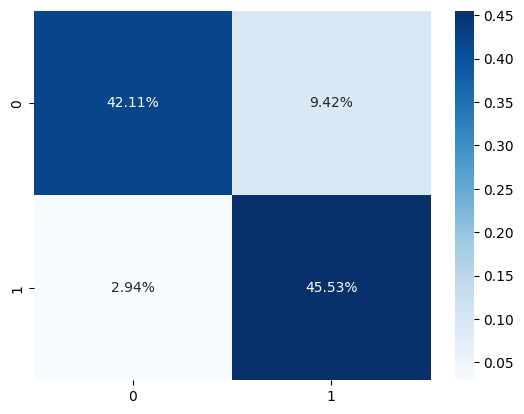

In [ ]:
# # Evaluate the model using cross-validation
xval_score = cross_val_score(clf_svm, X_train, y_train, cv=crossvalidation)

# Compute the basic statistics
accuracy_mean = np.average(xval_score)
accuracy_std = np.std(xval_score)

# Fit the classifier to the training data
clf_svm.fit(X_train, y_train)

# Make predictions on the test data
yp = clf_svm.predict(X_test)

# Get probability values
yprob = clf_svm.predict_proba(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, yp)

# Classification Report
class_report = classification_report(y_test, yp)

# Calculate evaluation metrics
precision = precision_score(y_test, yp)
recall = recall_score(y_test, yp)
accuracy = accuracy_score(y_test, yp)
# f1 = f1_score(y_test, yp)


print('Support Vector Machine Classifier')  # Print method name
print("========================================")
print(f"Accuracy (CV): {accuracy_mean:.3f} +/- {accuracy_std:.3f}")
print(f"Accuracy (Test): {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
# print(f"F1-Score: {f1:.3f}")
print("\n")
print('Classification Report:')
print(class_report)
print('Confusion Matrix:')
print('\t\tPredicted Flooded\tPredicted Not-Flooded')
print('Actual Flooded\t\t', conf_matrix[0][0], '\t\t', conf_matrix[0][1])
print('Actual Not-Flooded\t\t', conf_matrix[1][0], '\t\t', conf_matrix[1][1])


sns.heatmap(conf_matrix/np.sum(conf_matrix), annot=True,
            fmt='.2%', cmap='Blues')

In [ ]:
import joblib
joblib.dump(clf_svm, '/content/drive/MyDrive/GEE_exports/svm_alamo.joblib')

# later...
best_model_svm = joblib.load('/content/drive/MyDrive/GEE_exports/svm_alamo.joblib')

# Random Forest
Now we create a model for Random Forest to classify the pixels using the same Test and Validation datasets

In [ ]:
# Selecting all the properties columns as predictor variables
predictor_columns = bandsOfInterest

# Train-Test Split
X_train = df_train[predictor_columns]
y_train = df_train['class']
X_test = df_val[predictor_columns]
y_test = df_val['class']

# Training the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print(X_train.head())
# print(y_train.head())

   B1_diff  B2_diff  B3_diff  B4_diff  B5_diff  B6_diff  B7_diff  B8_diff  \
0   0.0181   0.0169   0.0197   0.0093   0.0099   0.0217   0.0421   0.0536   
1  -0.0010   0.0079   0.0051  -0.0026   0.0026   0.0796   0.1223   0.0680   
2   0.0111   0.0150   0.0197   0.0080   0.0121   0.0497   0.1284   0.0868   
3   0.0002   0.0020   0.0118  -0.0071   0.0195   0.1139   0.1419   0.1416   
4   0.0195   0.0123   0.0076  -0.0017   0.0062   0.0169   0.0215   0.0248   

   B8A_diff  B9_diff  B11_diff  B12_diff  MNDWI_diff  NDWI_diff  NDVI_diff  \
0    0.0389   0.0667    0.0331    0.0183    0.077216   0.054925  -0.104285   
1    0.1030   0.0801    0.0167    0.0093   -0.003667  -0.012842   0.041204   
2    0.1080   0.1019    0.0475    0.0169    0.035490   0.032410  -0.067371   
3    0.1682   0.1301    0.1037    0.0413   -0.163164  -0.143322   0.132562   
4    0.0474   0.0391    0.1309    0.0956   -0.246940   0.008214   0.039212   

   NDBI_diff  NDTI_diff  AWEIsh_diff  
0  -0.104285  -0.104285    -0

# Reducing the number of features: Sequential Feature Selection

The sequential feature selection tool provides a simple assesment of the features that carry the most information for the classification task at hand.


In [ ]:

# This classifier will only be used for the SFS, later another one will be tuned with GridSearch for the correct Hyperparameter selection
rf_default = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
)

sfs_rf = SequentialFeatureSelector(
    rf_default,
    n_features_to_select='auto',
    tol=0.001,                       # stop when CV score improves by < 0.1%
    direction='forward',
    scoring='accuracy',                    # or 'roc_auc' if you care about ranking
    cv=crossvalidation,
    n_jobs=-1,
)
sfs_rf.fit(X_train, y_train)

selected_features_rf = sfs_rf.get_feature_names_out(input_features = bandsOfInterest)
print('Selected:', list(selected_features_rf))

Selected: ['B1_diff', 'B5_diff', 'B8A_diff', 'B9_diff', 'B12_diff', 'MNDWI_diff', 'NDWI_diff']


In [ ]:
# Selecting all the properties columns as predictor variables
# Train-Test Split
X_train = df_train[selected_features_rf]
y_train = df_train['class']
X_test = df_val[selected_features_rf]
y_test = df_val['class']


In [ ]:
# Initialize the Random Forest classifier
# clf_rf = RandomForestClassifier(oob_score=True, max_depth= 10, min_samples_leaf= 4, min_samples_split= 2, n_estimators= 100)
# clf_rf = RandomForestClassifier(oob_score=True, max_depth= None, min_samples_leaf= 1, min_samples_split= 2, n_estimators= 300)
####
# Define the model and hyperparameters for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_forest = RandomForestClassifier(random_state=42,n_jobs=-1)
grid_search = GridSearchCV(random_forest, param_grid, cv=crossvalidation, scoring='accuracy', n_jobs=-1, verbose=3, refit=True ) # Controls the verbosity: the higher, the more messages (>1 : the computation time for each fold and parameter candidate is displayed)

# Perform grid search to find the best hyperparameters
grid_search.fit(X_train, y_train)
clf_rf = grid_search.best_estimator_
grid_search.best_params_

# Print the best hyperparameters found
print("Best Hyperparameters:", grid_search.best_params_)
# ####


joblib.dump(clf_rf, '/content/drive/MyDrive/GEE_exports/rf_alamo.joblib')

# later...
best_model_rf = joblib.load('/content/drive/MyDrive/GEE_exports/rf_alamo.joblib')


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest
Accuracy (CV): 0.874 +/- 0.017
Accuracy (Test): 0.885
Precision: 0.850
Recall: 0.927


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       421
           1       0.85      0.93      0.89       396

    accuracy                           0.88       817
   macro avg       0.89      0.89      0.88       817
weighted avg       0.89      0.88      0.88       817

Confusion Matrix:
		Predicted Burned	Predicted Unburned
Actual Burned		 356 		 65
Actual Unburned		 29 		 367


Classification Report:
              precision    recall  f1-score   support

    No Flood     0.9247    0.8456    0.8834       421
       Flood     0.8495    0.9268    0.8865       396

    accuracy                         0.8849       817
   macro avg     0.8871    0.8862    0.8849       817
weighted avg     0.8883    0.8849    0.8849       817


Confusion Matrix:
                 Predicted No Flood  Predicted Flood
Actual No Flood                 356               65
Actual Flood                     29              367


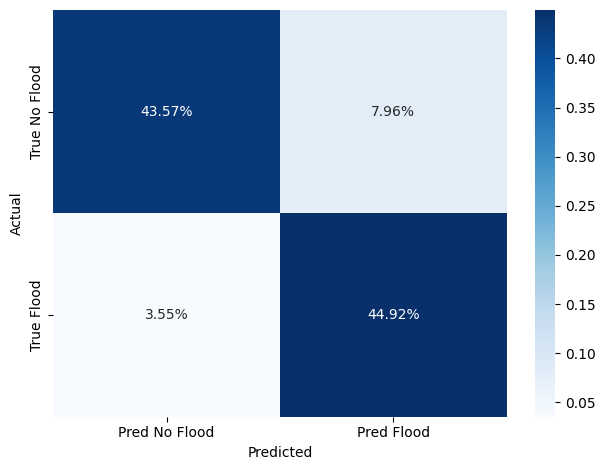

In [ ]:
# # Evaluate the model using cross-validation
xval_score = cross_val_score(clf_rf, X_train, y_train, cv=crossvalidation)

# Compute the basic statistics
accuracy_mean = np.average(xval_score)
accuracy_std = np.std(xval_score)

# Fit the classifier to the training data
clf_rf.fit(X_train, y_train)

# Make predictions on the test data
yp = clf_rf.predict(X_test)

# Get probability values
yprob = clf_rf.predict_proba(X_test)

# Define ONCE, in encoding order (index = class integer)
class_labels = [0, 1]
class_names  = ['No Flood', 'Flood']   # 0 = No Flood, 1 = Flood

# --- Classification report (labels + target_names kept in lockstep) ---
class_report = classification_report(
    y_test, yp,
    labels=class_labels,
    target_names=class_names,
    digits=4,
)
print('Classification Report Random Forest:')
print(class_report)

# --- Confusion matrix with explicit label order ---
conf_matrix = confusion_matrix(y_test, yp, labels=class_labels)

# Rows = actual, Cols = predicted; both follow class_names order
cm_df = pd.DataFrame(
    conf_matrix,
    index=[f'Actual {n}' for n in class_names],
    columns=[f'Predicted {n}' for n in class_names],
)
print('\nConfusion Matrix Random Forest:')
print(cm_df)

# --- Heatmap (normalized), correctly labeled ---
sns.heatmap(
    conf_matrix / conf_matrix.sum(),
    annot=True, fmt='.2%', cmap='Blues',
    xticklabels=[f'Pred {n}' for n in class_names],
    yticklabels=[f'True {n}' for n in class_names],
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

<Axes: >

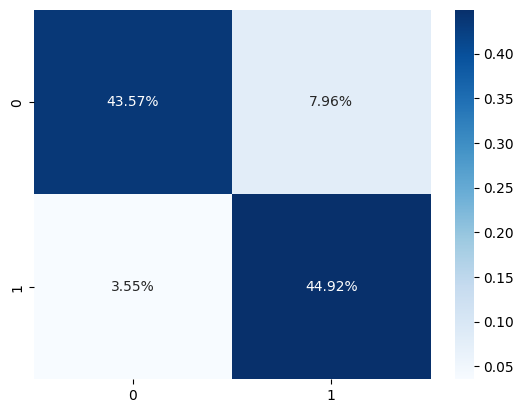

In [ ]:
cmrf = np.array([[348,  73],
       [ 29, 367]])

sns.heatmap(conf_matrix/np.sum(conf_matrix), annot=True,
            fmt='.2%', cmap='Blues')

# Applying the models
The classification models are applied to the whole raster collection.

The manipulation of the raster files is done with rasterio.

In [ ]:
# ============================================================
# Apply trained models to the full feature stack
# ============================================================
from pathlib import Path
import numpy as np
import rasterio

EXPORT_DIR = Path('/content/drive/MyDrive/GEE_exports')
FEATURES_TIF = EXPORT_DIR / 'features_alamo.tif'
OUT_SVM_TIF  = EXPORT_DIR / 'AlamoFlood_SVM.tif'
OUT_RF_TIF   = EXPORT_DIR / 'AlamoFlood_RF.tif'

for out_path,selected_bands,model in [(OUT_SVM_TIF,sfs_svm.get_support(),best_model_svm), (OUT_RF_TIF,sfs_rf.get_support(), best_model_rf)]: #, (OUT_RF_TIF, y_rf)
  # --- Load the feature stack ---
  with rasterio.open(FEATURES_TIF) as src:
      stack = src.read()[selected_bands]                       # shape: (n_bands, H, W)
      profile = src.profile
      transform = src.transform
      crs = src.crs

  n_bands, H, W = stack.shape
  # assert n_bands == len(bandsOfInterest), (
  #     f"Mismatch: raster has {n_bands} bands but model expects "
  #     f"{len(bandsOfInterest)} ({bandsOfInterest})"
  # )

  # --- Reshape to (n_pixels, n_bands) and identify clean pixels ---
  X_img = stack.reshape(n_bands, -1).T              # (n_pixels, n_bands)
  valid = ~np.isnan(X_img).any(axis=1)              # True where all bands are valid

  # --- Separate arrays (avoid memory aliasing) ---
  y = np.zeros(X_img.shape[0], dtype=np.uint8)
  # y_rf  = np.zeros(X_img.shape[0], dtype=np.uint8)

  y[valid] = model.predict(X_img[valid]).astype(np.uint8)
  # y_rf[valid]  = best_model_rf.predict(X_img[sfs_ rf.get_support()]).astype(np.uint8)

  # --- Reshape back to image grid ---
  y = y.reshape(H, W)
  # y_rf  = y_rf.reshape(H, W)

  # --- Write as single-band uint8 GeoTIFFs, preserving georeferencing ---
  out_profile = profile.copy()
  out_profile.update(count=1, dtype='uint8', compress='lzw', nodata=255)

  with rasterio.open(out_path, 'w', **out_profile) as dst:
      dst.write(y, 1)
  print(f"Wrote {out_path}")

Wrote /content/drive/MyDrive/GEE_exports/AlamoFlood_SVM.tif


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Wrote /content/drive/MyDrive/GEE_exports/AlamoFlood_RF.tif


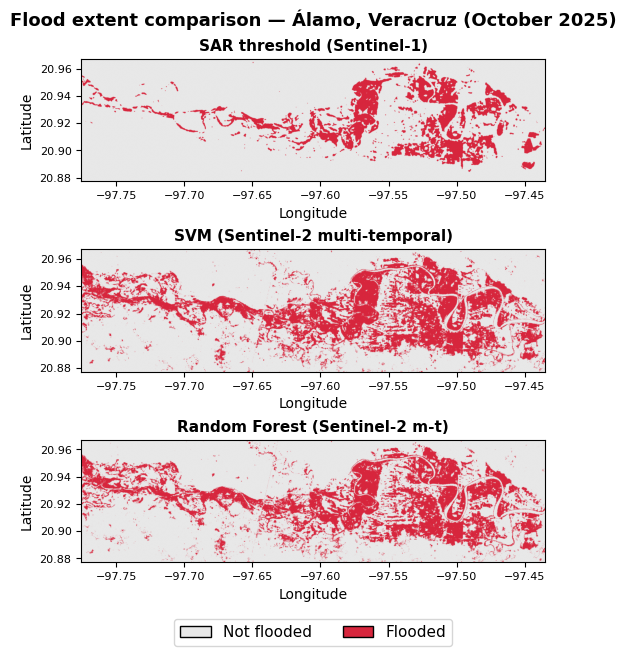

In [ ]:
# ============================================================
# Comparison of three flood-detection products
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from pathlib import Path

# --- File registry: one source of truth ---
EXPORT_DIR = Path('/content/drive/MyDrive/GEE_exports')
PRODUCTS = {
    'SAR threshold (Sentinel-1)':       EXPORT_DIR / 'AlamoFlood_SAR_Mask.tif',
    'SVM (Sentinel-2 multi-temporal)':  EXPORT_DIR / 'AlamoFlood_SVM.tif',
    'Random Forest (Sentinel-2 m-t)':   EXPORT_DIR / 'AlamoFlood_RF.tif',
}

# --- Visual style (consistent across all panels) ---
PALETTE = {
    'no_flood': '#e8e8e8',   # light grey
    'flood':    '#d7263d',   # red
}
cmap = ListedColormap([PALETTE['no_flood'], PALETTE['flood']])
legend_handles = [
    Patch(facecolor=PALETTE['no_flood'], edgecolor='black', label='Not flooded'),
    Patch(facecolor=PALETTE['flood'],    edgecolor='black', label='Flooded'),
]

# --- Load all three rasters once, store with their extents ---
def load_binary_raster(path):
    """Return (data, extent) with a robust binary cast."""
    with rasterio.open(path) as src:
        data = src.read(1)
        extent = plotting_extent(src)
        pixel_area_ha = abs(src.res[0] * src.res[1]) / 10_000  # m² → ha
    # Defensive: collapse anything > 0 to 1, keep NaN-safe
    data = np.where(np.isnan(data) if data.dtype.kind == 'f' else False, 0, data)
    return (data > 0).astype(np.uint8), extent, pixel_area_ha

rasters = {name: load_binary_raster(path) for name, path in PRODUCTS.items()}

# --- Plot side by side ---
fig, axes = plt.subplots(3, 1, figsize=(15, 6), constrained_layout=True)

for ax, (name, (data, extent, _)) in zip(axes, rasters.items()):
    ax.imshow(data, cmap=cmap, vmin=0, vmax=1, extent=extent ) #interpolation='nearest'
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.tick_params(labelsize=8)

# Single legend for all panels
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.08),
    frameon=True,
    fontsize=11,
)
fig.suptitle('Flood extent comparison — Álamo, Veracruz (October 2025)',
             fontsize=13, fontweight='bold')
plt.show()

# Numerical Analysis and Statistics


In [ ]:
# ============================================================
# Quantitative comparison: area, agreement, IoU
# ============================================================
import pandas as pd

def iou(a, b):
    """Intersection over Union for two binary arrays of equal shape."""
    a, b = a.astype(bool), b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else np.nan

# --- Per-product flooded area ---
rows = []
for name, (data, _, px_ha) in rasters.items():
    flooded_px = int(data.sum())
    rows.append({
        'Product': name,
        'Flooded pixels': flooded_px,
        'Flooded area (m2)': round(flooded_px * 0.001 , 1),
        'Coverage (%)': round(100 * flooded_px / data.size, 2),
    })
area_df = pd.DataFrame(rows)
print('--- Flooded area per product ---')
print(area_df.to_string(index=False))

# --- Pairwise IoU (Jaccard index) ---
names = list(rasters.keys())
iou_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for i, ni in enumerate(names):
    for nj in names:
        iou_matrix.loc[ni, nj] = iou(rasters[ni][0], rasters[nj][0])

print('\n--- Pairwise IoU (Jaccard index) ---')
print(iou_matrix.round(3).to_string())

--- Flooded area per product ---
                        Product  Flooded pixels  Flooded area (m2)  Coverage (%)
     SAR threshold (Sentinel-1)          495745             495745         13.06
SVM (Sentinel-2 multi-temporal)          977630             977630         25.75
 Random Forest (Sentinel-2 m-t)          929166             929166         24.47

--- Pairwise IoU (Jaccard index) ---
                                 SAR threshold (Sentinel-1)  SVM (Sentinel-2 multi-temporal)  Random Forest (Sentinel-2 m-t)
SAR threshold (Sentinel-1)                            1.000                            0.439                           0.453
SVM (Sentinel-2 multi-temporal)                       0.439                            1.000                           0.824
Random Forest (Sentinel-2 m-t)                        0.453                            0.824                           1.000


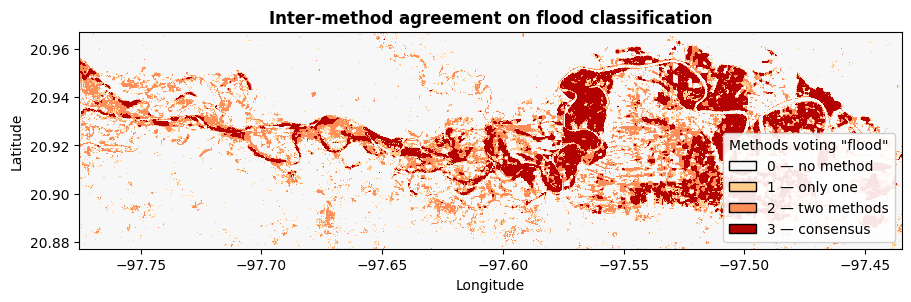


--- Agreement breakdown ---
  0 method(s):  2,720,598 px (71.66%,      0.0 ha)
  1 method(s):    229,144 px ( 6.04%,      0.0 ha)
  2 method(s):    414,298 px (10.91%,      0.0 ha)
  3 method(s):    432,753 px (11.40%,      0.0 ha)


In [ ]:
# ============================================================
# Agreement map: how many methods classify each pixel as flood
# ============================================================
arrays = [data for data, _, _ in rasters.values()]
# Resize sanity check
shape0 = arrays[0].shape
assert all(a.shape == shape0 for a in arrays), "Rasters must share the same shape/extent"

agreement = np.sum(arrays, axis=0).astype(np.uint8)   # values: 0, 1, 2, 3

# Diverging discrete palette: 0=no flood, 1=weak, 2=moderate, 3=consensus
agreement_palette = ['#f7f7f7', '#fdcc8a', '#fc8d59', '#b30000']
agreement_cmap = ListedColormap(agreement_palette)
agreement_labels = [
    Patch(facecolor=agreement_palette[0], edgecolor='black', label='0 — no method'),
    Patch(facecolor=agreement_palette[1], edgecolor='black', label='1 — only one'),
    Patch(facecolor=agreement_palette[2], edgecolor='black', label='2 — two methods'),
    Patch(facecolor=agreement_palette[3], edgecolor='black', label='3 — consensus'),
]

# Use the extent of the first raster (all share it)
_, ref_extent, ref_px_ha = next(iter(rasters.values()))

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
ax.imshow(agreement, cmap=agreement_cmap, vmin=0, vmax=3,
          extent=ref_extent, interpolation='nearest')
ax.set_title('Inter-method agreement on flood classification',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(handles=agreement_labels, loc='lower right',
          title='Methods voting "flood"', framealpha=0.9)
plt.show()

# --- Agreement statistics ---
total_px = agreement.size
print('\n--- Agreement breakdown ---')
for k in range(4):
    n = int((agreement == k).sum())
    print(f'  {k} method(s): {n:>10,} px '
          f'({100*n/total_px:5.2f}%, {n*ref_px_ha:8.1f} ha)')

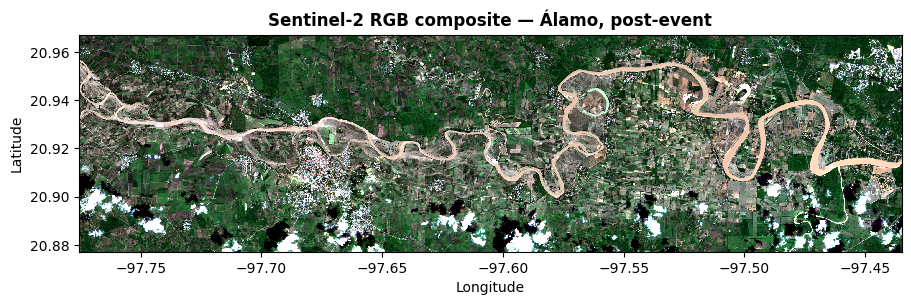

In [ ]:
# ============================================================
# RGB composite of the AOI (Sentinel-2, post-event)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from pathlib import Path

RGB_TIF = '/content/drive/MyDrive/GEE_exports/alamo_after.tif'

# Sentinel-2 band order in your export (adjust if different)
# Assumes bands are stored as [B1, B2, B3, B4, B5, ...] following native S2 order
BAND_INDEX = {'B2': 2, 'B3': 3, 'B4': 4}   # 1-based indexing for rasterio.read()

def stretch(band, lo_pct=2, hi_pct=98):
    """Percentile stretch for display; clips extremes and rescales to [0, 1]."""
    lo, hi = np.nanpercentile(band, [lo_pct, hi_pct])
    return np.clip((band - lo) / (hi - lo + 1e-9), 0, 1)

with rasterio.open(RGB_TIF) as src:
    red   = src.read(BAND_INDEX['B4']).astype('float32')
    green = src.read(BAND_INDEX['B3']).astype('float32')
    blue  = src.read(BAND_INDEX['B2']).astype('float32')
    extent = plotting_extent(src)

# Stack into (H, W, 3) and apply per-band stretch for a natural-looking image
rgb = np.dstack([stretch(red), stretch(green), stretch(blue)])

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
ax.imshow(rgb, extent=extent, interpolation='nearest')
ax.set_title('Sentinel-2 RGB composite — Álamo, post-event', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

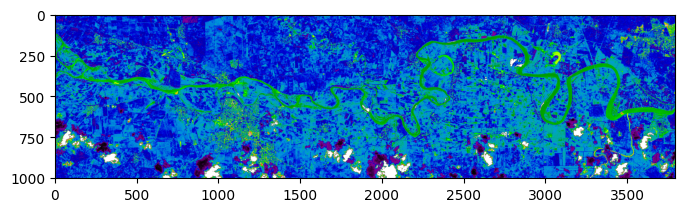

In [ ]:
# ============================================================
# RGB composite of the AOI (Sentinel-2, post-event)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from pathlib import Path

RGB_TIF = '/content/drive/MyDrive/GEE_exports/alamo_after.tif'

SpectralIndexes = [
  'MNDWI_diff',
  'NDWI_diff',
  'NDVI_diff',
  'NDBI_diff',
  'NDTI_diff',
  'AWEIsh_diff',
]


with rasterio.open(RGB_TIF) as src:
    band   = src.read(bandsOfInterest.index('AWEIsh_diff')).astype('float32')
    extent = plotting_extent(src)

fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show(band, cmap="nipy_spectral", ax=ax) # title="Digital Elevation Model (DEM)"
plt.show()

# fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
# ax.imshow(rgb, extent=extent, interpolation='nearest')
# ax.set_title('Sentinel-2 RGB composite — Álamo, post-event', fontsize=12, fontweight='bold')
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
# plt.show()

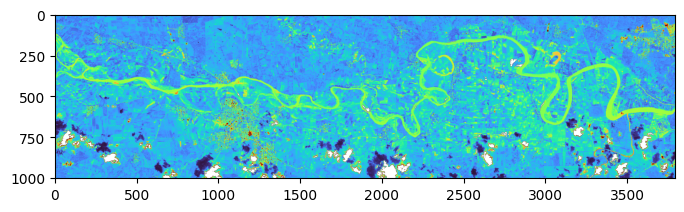

In [ ]:
# ============================================================
# RGB composite of the AOI (Sentinel-2, post-event)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from pathlib import Path

RGB_TIF = '/content/drive/MyDrive/GEE_exports/alamo_after.tif'

SpectralIndexes = [
  'MNDWI_diff',
  'NDWI_diff',
  'NDVI_diff',
  'NDBI_diff',
  'NDTI_diff',
  'AWEIsh_diff',
]


with rasterio.open(RGB_TIF) as src:
    band   = src.read(bandsOfInterest.index('AWEIsh_diff')).astype('float32')
    extent = plotting_extent(src)

fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show(band, cmap="turbo", ax=ax) # title="Digital Elevation Model (DEM)"
plt.show()

# fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
# ax.imshow(rgb, extent=extent, interpolation='nearest')
# ax.set_title('Sentinel-2 RGB composite — Álamo, post-event', fontsize=12, fontweight='bold')
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
# plt.show()